In [3]:
import pandas as pd

df = pd.read_csv('../data/petrol_gas_price_analysis_clean.csv')
df.head()

,Date,Country,Region,Petrol_Price_USD_per_Liter,Diesel_Price_USD_per_Liter,Natural_Gas_Price_USD_per_MMBtu,Crude_Oil_Price_USD_per_Barrel,Inflation_Rate (%),Exchange_Rate_vs_USD,GDP_Growth (%),...,Geopolitical_Risk_Index,Event_Flag,Event_Description,Currency_Devaluation (%),Subsidy_Level,Tax_Rate_on_Fuel (%),Petrol_7d_MA,Petrol_28d_vol,Petrol_lag_1,Crude_lag_1
0,2015-01-05,Brazil,Latin America,0.675,0.609,1.769,50.91,2.42,5.1316,0.58,...,20.4,0,NaN,0.32,Medium,20.0,0.675000,NaN,NaN,NaN
1,2015-01-12,Brazil,Latin America,0.687,0.602,1.565,51.57,3.39,5.2201,2.08,...,23.5,0,NaN,-0.41,Medium,20.0,0.681000,NaN,0.675,50.91
2,2015-01-19,Brazil,Latin America,0.710,0.642,1.760,53.96,2.03,5.0857,3.43,...,21.1,0,NaN,0.35,Medium,20.0,0.690667,0.011102,0.687,51.57
3,2015-01-26,Brazil,Latin America,0.802,0.713,1.500,58.69,2.30,5.2486,1.96,...,24.5,0,NaN,-0.46,Medium,20.0,0.718500,0.060526,0.710,53.96
4,2015-02-02,Brazil,Latin America,0.685,0.650,1.500,52.61,1.96,5.2284,1.83,...,25.4,0,NaN,-0.74,Medium,20.0,0.721000,0.114316,0.802,58.69


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5860 entries, 0 to 5859
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             5860 non-null   str    
 1   Country                          5860 non-null   str    
 2   Region                           5860 non-null   str    
 3   Petrol_Price_USD_per_Liter       5860 non-null   float64
 4   Diesel_Price_USD_per_Liter       5860 non-null   float64
 5   Natural_Gas_Price_USD_per_MMBtu  5860 non-null   float64
 6   Crude_Oil_Price_USD_per_Barrel   5860 non-null   float64
 7   Inflation_Rate (%)               5860 non-null   float64
 8   Exchange_Rate_vs_USD             5860 non-null   float64
 9   GDP_Growth (%)                   5860 non-null   float64
 10  Supply_Index                     5860 non-null   float64
 11  Demand_Index                     5860 non-null   float64
 12  Geopolitical_Risk_Index        

In [5]:
df.describe()

,Petrol_Price_USD_per_Liter,Diesel_Price_USD_per_Liter,Natural_Gas_Price_USD_per_MMBtu,Crude_Oil_Price_USD_per_Barrel,Inflation_Rate (%),Exchange_Rate_vs_USD,GDP_Growth (%),Supply_Index,Demand_Index,Geopolitical_Risk_Index,Event_Flag,Currency_Devaluation (%),Tax_Rate_on_Fuel (%),Petrol_7d_MA,Petrol_28d_vol,Petrol_lag_1,Crude_lag_1
count,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5860.000000,5840.000000,5850.000000,5850.000000
mean,0.838600,0.752848,1.776439,57.443406,3.096753,41.957688,1.997531,50.200444,50.131365,28.570802,0.166724,0.002493,25.600000,0.837801,0.067361,0.838253,57.419603
std,0.199531,0.175306,0.300398,9.904936,1.684595,80.398213,1.484169,8.589973,8.933544,9.133853,0.372761,0.498575,12.052584,0.194522,0.019811,0.199433,9.896569
min,0.381000,0.363000,1.500000,35.590000,0.240000,0.726000,-3.180000,20.400000,19.200000,20.000000,0.000000,-1.680000,10.000000,0.428250,0.002337,0.381000,35.590000
25%,0.690000,0.622750,1.500000,49.710000,2.180000,0.987775,1.000000,44.400000,44.175000,23.000000,0.000000,-0.340000,18.000000,0.692750,0.053716,0.690000,49.710000
50%,0.814000,0.731000,1.687000,56.745000,2.620000,6.438800,1.990000,50.100000,50.100000,26.100000,0.000000,0.000000,22.500000,0.816000,0.065127,0.813000,56.710000
75%,0.965000,0.863000,1.958000,63.760000,3.220000,74.064575,3.000000,56.000000,56.100000,29.000000,0.000000,0.330000,38.000000,0.960500,0.077718,0.964750,63.710000
max,1.601000,1.424000,3.140000,91.850000,11.410000,532.271200,7.870000,79.500000,82.600000,69.500000,1.000000,1.760000,45.000000,1.533500,0.145735,1.601000,91.850000


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].head()

0   2015-01-05
1   2015-01-12
2   2015-01-19
3   2015-01-26
4   2015-02-02
Name: Date, dtype: datetime64[us]

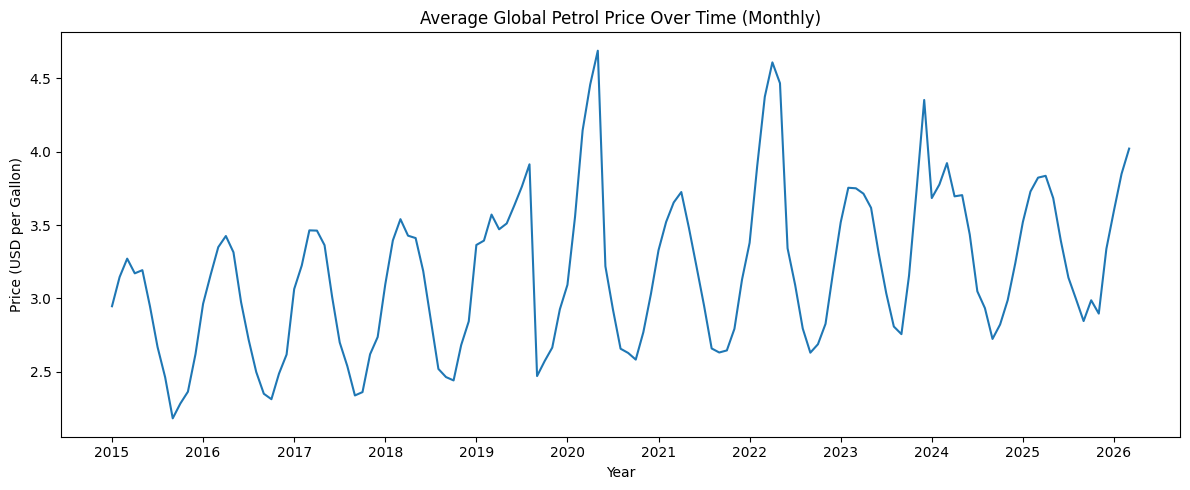

In [20]:
avg_price_monthly = df.groupby(df['Date'].dt.to_period('M'))['Petrol_Price_USD_per_Liter'].mean() * 3.785

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_price_monthly.index.astype(str), avg_price_monthly.values)
ax.set_title('Average Global Petrol Price Over Time (Monthly)')
ax.set_xlabel('Year')
ax.set_ylabel('Price (USD per Gallon)')

year_positions = [i for i, label in enumerate(avg_price_monthly.index.astype(str)) if label.endswith('01')]
year_labels = [label[:4] for label in avg_price_monthly.index.astype(str) if label.endswith('01')]
ax.set_xticks(year_positions)
ax.set_xticklabels(year_labels)

plt.tight_layout()
plt.savefig('../website/charts/price_trends_monthly.png')
plt.show()

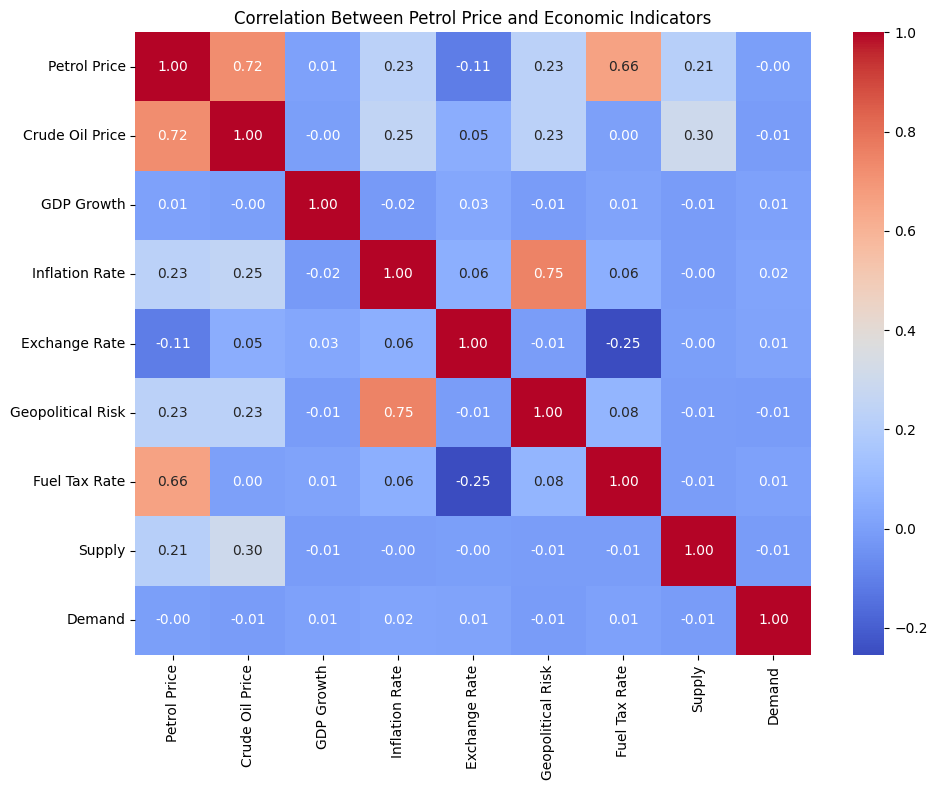

In [12]:
readable_names = {
    'Petrol_Price_USD_per_Liter': 'Petrol Price',
    'Crude_Oil_Price_USD_per_Barrel': 'Crude Oil Price',
    'GDP_Growth (%)': 'GDP Growth',
    'Inflation_Rate (%)': 'Inflation Rate',
    'Exchange_Rate_vs_USD': 'Exchange Rate',
    'Geopolitical_Risk_Index': 'Geopolitical Risk',
    'Tax_Rate_on_Fuel (%)': 'Fuel Tax Rate',
    'Supply_Index': 'Supply',
    'Demand_Index': 'Demand'
}

corr_matrix_readable = df[correlation_cols].corr().rename(
    index=readable_names, columns=readable_names
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_readable, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Petrol Price and Economic Indicators')
plt.tight_layout()
plt.savefig('../website/charts/correlation_heatmap.png')
plt.show()

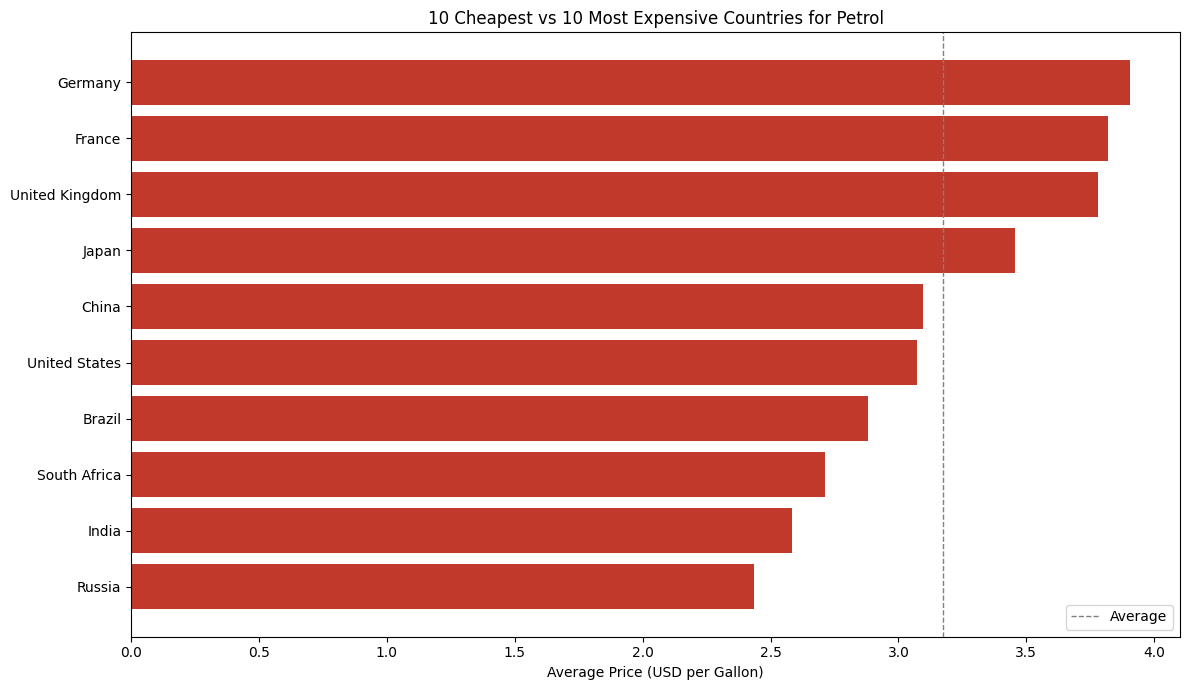

In [21]:
avg_by_country = df.groupby('Country')['Petrol_Price_USD_per_Liter'].mean().sort_values() * 3.785

top10_cheap = avg_by_country.head(10)
top10_expensive = avg_by_country.tail(10)
combined = pd.concat([top10_cheap, top10_expensive])

colors = ['#2ecc71'] * 10 + ['#c0392b'] * 10

plt.figure(figsize=(12, 7))
bars = plt.barh(combined.index, combined.values, color=colors)
plt.axvline(combined.values.mean(), color='gray', linestyle='--', linewidth=1, label='Average')
plt.title('10 Cheapest vs 10 Most Expensive Countries for Petrol')
plt.xlabel('Average Price (USD per Gallon)')
plt.legend()
plt.tight_layout()
plt.savefig('../website/charts/country_comparison.png')
plt.show()

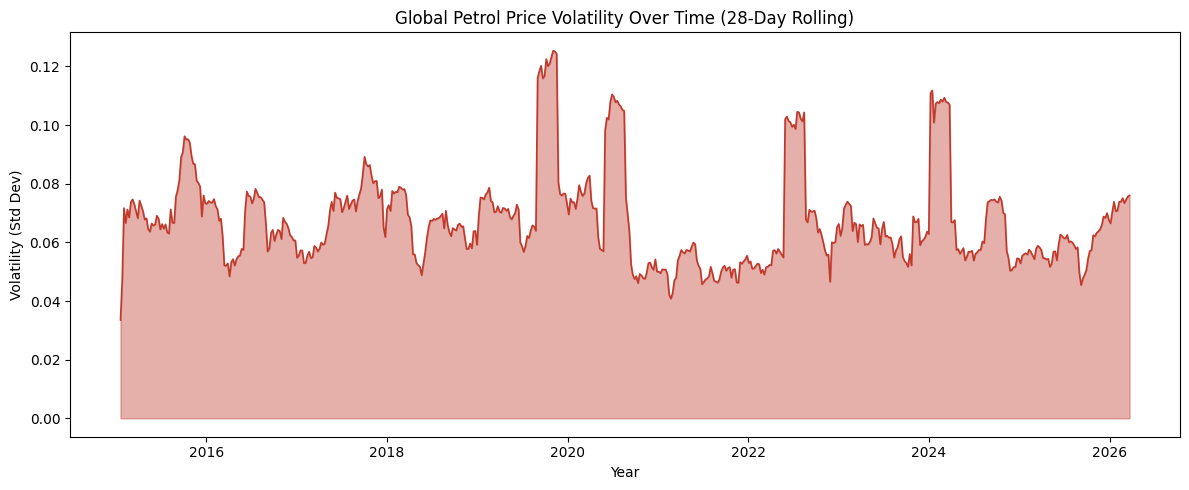

In [14]:
avg_volatility = df.groupby('Date')['Petrol_28d_vol'].mean()

plt.figure(figsize=(12, 5))
plt.fill_between(avg_volatility.index, avg_volatility.values, alpha=0.4, color='#c0392b')
plt.plot(avg_volatility.index, avg_volatility.values, color='#c0392b', linewidth=1.2)
plt.title('Global Petrol Price Volatility Over Time (28-Day Rolling)')
plt.xlabel('Year')
plt.ylabel('Volatility (Std Dev)')
plt.tight_layout()
plt.savefig('../website/charts/volatility.png')
plt.show()

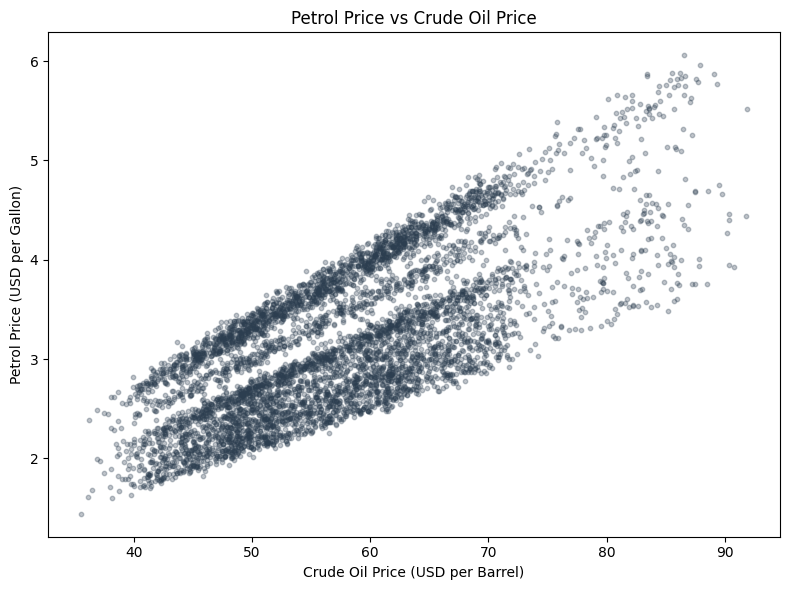

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Crude_Oil_Price_USD_per_Barrel'], df['Petrol_Price_USD_per_Liter'] * 3.785, 
            alpha=0.3, s=10, color='#2c3e50')
plt.title('Petrol Price vs Crude Oil Price')
plt.xlabel('Crude Oil Price (USD per Barrel)')
plt.ylabel('Petrol Price (USD per Gallon)')
plt.tight_layout()
plt.savefig('../website/charts/petrol_vs_crude.png')
plt.show()

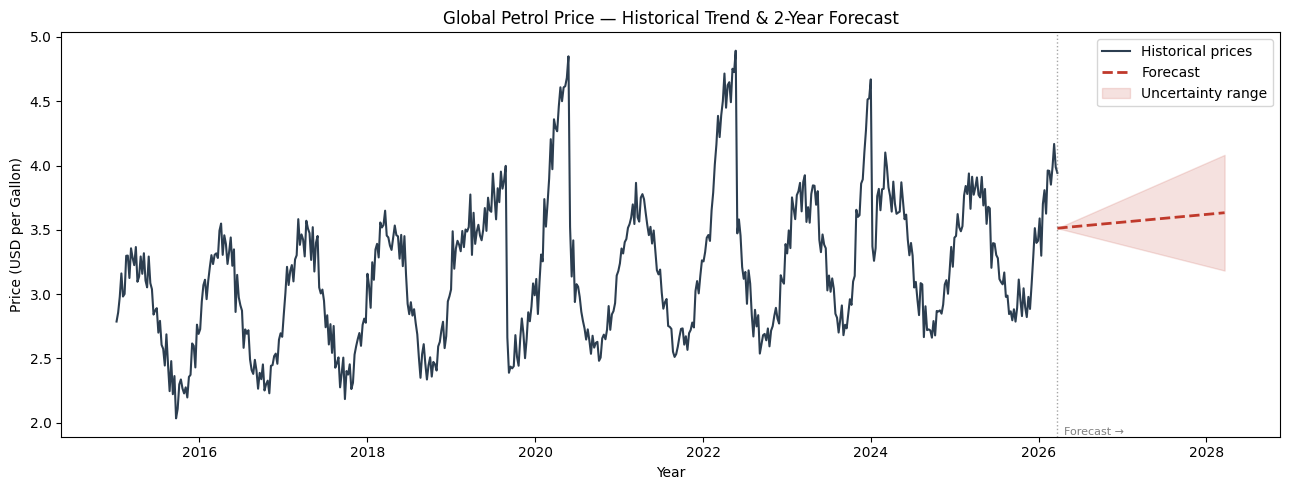

In [23]:
from sklearn.linear_model import LinearRegression
import numpy as np

avg_price = df.groupby('Date')['Petrol_Price_USD_per_Liter'].mean().reset_index()
avg_price = avg_price.dropna()
avg_price['Price_per_Gallon'] = avg_price['Petrol_Price_USD_per_Liter'] * 3.785

avg_price['Date_num'] = (avg_price['Date'] - avg_price['Date'].min()).dt.days
X = avg_price['Date_num'].values.reshape(-1, 1)
y = avg_price['Price_per_Gallon'].values

model = LinearRegression()
model.fit(X, y)

last_day = avg_price['Date_num'].max()
last_date = avg_price['Date'].max()

future_days = np.arange(last_day, last_day + 730, 7).reshape(-1, 1)
future_dates = avg_price['Date'].min() + pd.to_timedelta(future_days.flatten(), unit='D')
future_prices = model.predict(future_days)

uncertainty = np.linspace(0, 0.45, len(future_days))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(avg_price['Date'], y, color='#2c3e50', linewidth=1.5, label='Historical prices')
ax.plot(future_dates, future_prices, color='#c0392b', linewidth=2, linestyle='--', label='Forecast')
ax.fill_between(future_dates,
                future_prices - uncertainty,
                future_prices + uncertainty,
                alpha=0.15, color='#c0392b', label='Uncertainty range')
ax.axvline(last_date, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax.text(last_date, ax.get_ylim()[0], '  Forecast →', fontsize=8, color='gray', va='bottom')
ax.set_title('Global Petrol Price — Historical Trend & 2-Year Forecast')
ax.set_xlabel('Year')
ax.set_ylabel('Price (USD per Gallon)')
ax.legend()
plt.tight_layout()
plt.savefig('../website/charts/forecast.png')
plt.show()

In [24]:
print("Min per gallon:", df['Petrol_Price_USD_per_Liter'].min() * 3.785)
print("Max per gallon:", df['Petrol_Price_USD_per_Liter'].max() * 3.785)

Min per gallon: 1.442085
Max per gallon: 6.059785


In [25]:
min_idx = df['Petrol_Price_USD_per_Liter'].idxmin()
print(df.loc[min_idx, ['Date', 'Country', 'Petrol_Price_USD_per_Liter']])

Date                          2015-09-21 00:00:00
Country                                    Russia
Petrol_Price_USD_per_Liter                  0.381
Name: 3553, dtype: object
